# ERA5 Land Data Processing

This notebook process the raw data downloaded from GEE server.

In [113]:
# Load libraries

import os
import pandas as pd
import matplotlib.pyplot as plt
import glob
import pyarrow as pa
print('Libraries loaded.')

pd.set_option('display.expand_frame_repr', False)

Libraries loaded.


In [110]:
# Imports and configurations -----------------------------------------------------------------------


# Paths and directories -----------------------------------------------------------------------
BASE_OUT_DIR = r'C:\Users\ibekar\Documents\GitProjects\TGPF'  # Windows
# BASE_OUT_DIR = '/Users/ibekar/Github/TGPF'                  # Mac

input_dir = os.path.join(BASE_OUT_DIR, 'inputs', 'raw_data', 'era5_raw')
save_dir = os.path.join(BASE_OUT_DIR, 'inputs', 'processed_data', 'era5')
os.makedirs(save_dir, exist_ok=True)
print(f'input directory: {input_dir}')
print(f'save directory: {save_dir}')

input directory: C:\Users\ibekar\Documents\GitProjects\TGPF\inputs\raw_data\era5_raw
save directory: C:\Users\ibekar\Documents\GitProjects\TGPF\inputs\processed_data\era5


In [ ]:
only_files = glob.glob(input_dir + "/*.csv")
era5 = pd.concat((pd.read_csv(f) for f in only_files))
print(era5.head())

   eco_id                            eco_name        date  temperature_K  precip_m
0     644  Appenine deciduous montane forests  2003-01-01     277.177294  0.003028
1     644  Appenine deciduous montane forests  2003-01-02     278.695070  0.001703
2     644  Appenine deciduous montane forests  2003-01-03     281.266783  0.002370
3     644  Appenine deciduous montane forests  2003-01-04     279.675098  0.002044
4     644  Appenine deciduous montane forests  2003-01-05     275.136487  0.005928


In [83]:
print(era5.columns)
print(era5.dtypes)
print(era5.isnull().sum())

Index(['eco_id', 'eco_name', 'date', 'year', 'doy', 'temperature_K',
       'precip_m', 'temperature_C', 'precip_mm'],
      dtype='object')
eco_id                    int64
eco_name                 object
date             datetime64[ns]
year                      int32
doy                       int32
temperature_K           float64
precip_m                float64
temperature_C           float64
precip_mm               float64
dtype: object
eco_id           0
eco_name         0
date             0
year             0
doy              0
temperature_K    0
precip_m         0
temperature_C    0
precip_mm        0
dtype: int64


In [67]:
# Unit conversion

era5["temperature_C"] = era5["temperature_K"] - 273.15
era5["precip_mm"] = era5["precip_m"] * 1000
print(era5.head())

   eco_id                            eco_name        date  temperature_K  precip_m  temperature_C  precip_mm
0     644  Appenine deciduous montane forests  2003-01-01     277.177294  0.003028       4.027294   3.028352
1     644  Appenine deciduous montane forests  2003-01-02     278.695070  0.001703       5.545070   1.702905
2     644  Appenine deciduous montane forests  2003-01-03     281.266783  0.002370       8.116783   2.370047
3     644  Appenine deciduous montane forests  2003-01-04     279.675098  0.002044       6.525098   2.044494
4     644  Appenine deciduous montane forests  2003-01-05     275.136487  0.005928       1.986487   5.928239


In [68]:
# parse date and extract year and doy

era5["date"] = pd.to_datetime(era5["date"])
era5["year"] = era5["date"].dt.year
era5["doy"] = era5["date"].dt.dayofyear
print(era5.head())

   eco_id                            eco_name       date  temperature_K  precip_m  temperature_C  precip_mm  year  doy
0     644  Appenine deciduous montane forests 2003-01-01     277.177294  0.003028       4.027294   3.028352  2003    1
1     644  Appenine deciduous montane forests 2003-01-02     278.695070  0.001703       5.545070   1.702905  2003    2
2     644  Appenine deciduous montane forests 2003-01-03     281.266783  0.002370       8.116783   2.370047  2003    3
3     644  Appenine deciduous montane forests 2003-01-04     279.675098  0.002044       6.525098   2.044494  2003    4
4     644  Appenine deciduous montane forests 2003-01-05     275.136487  0.005928       1.986487   5.928239  2003    5


In [69]:
# Reorder columns
ordered_first = ['eco_id', 'eco_name', 'date', 'year', 'doy']

rest = [c for c in era5.columns if c not in ordered_first]

# Combine and reindex
era5 = era5[ordered_first + rest]
print(era5.head())

   eco_id                            eco_name       date  year  doy  temperature_K  precip_m  temperature_C  precip_mm
0     644  Appenine deciduous montane forests 2003-01-01  2003    1     277.177294  0.003028       4.027294   3.028352
1     644  Appenine deciduous montane forests 2003-01-02  2003    2     278.695070  0.001703       5.545070   1.702905
2     644  Appenine deciduous montane forests 2003-01-03  2003    3     281.266783  0.002370       8.116783   2.370047
3     644  Appenine deciduous montane forests 2003-01-04  2003    4     279.675098  0.002044       6.525098   2.044494
4     644  Appenine deciduous montane forests 2003-01-05  2003    5     275.136487  0.005928       1.986487   5.928239


# Climatological baselines and anomalies

In [70]:
# calculate climatological baselines

climatology = era5.groupby(['eco_id', 'doy']).agg({
    'temperature_C': 'mean',
    'precip_mm': 'mean'
}).reset_index()

climatology.rename(columns={
    'temperature_C': 'temp_climatology',
    'precip_mm': 'precip_climatology'
}, inplace=True)
print(climatology.head())

   eco_id  doy  temp_climatology  precip_climatology
0     644    1          2.551830            3.287122
1     644    2          2.433287            3.033729
2     644    3          2.255907            3.129188
3     644    4          2.088226            2.331124
4     644    5          2.140970            4.247281


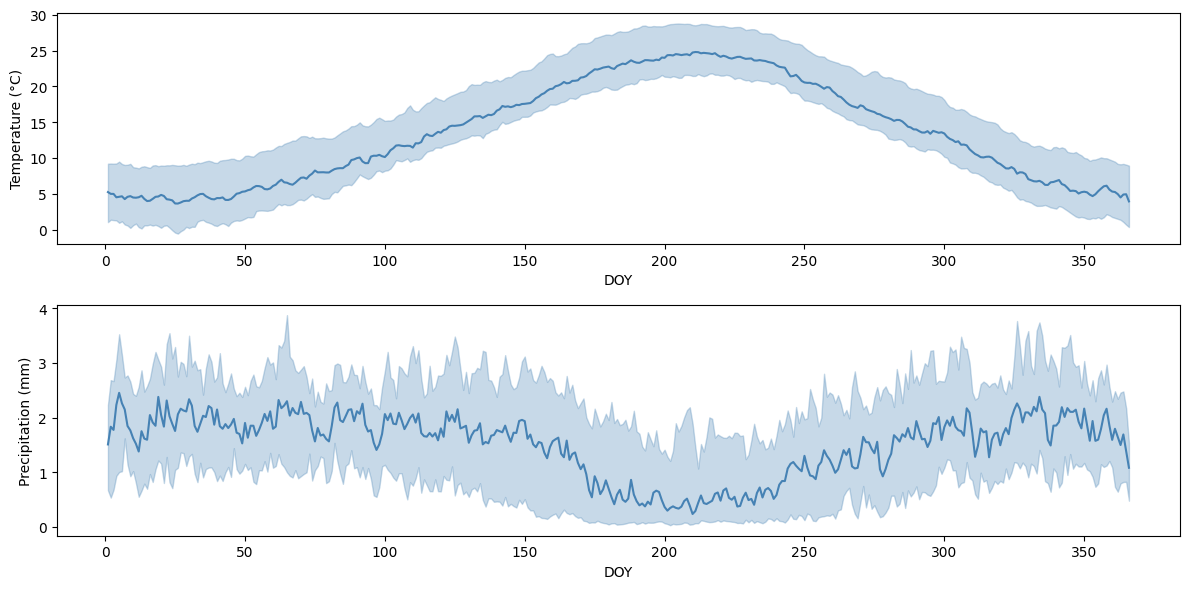

In [44]:
# ── Plot 1: Median seasonal cycle with IQR envelope ──────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

for ax, var, label in zip(axes,
                           ['temp_climatology', 'precip_climatology'],
                           ['Temperature (°C)', 'Precipitation (mm)']):
    grouped = climatology.groupby('doy')[var]
    median  = grouped.median()
    q25     = grouped.quantile(0.25)
    q75     = grouped.quantile(0.75)

    ax.plot(median.index, median.values, color='steelblue', lw=1.5)
    ax.fill_between(median.index, q25, q75, alpha=0.3, color='steelblue')
    ax.set_xlabel('DOY')
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()


# # ── Plot 2: Heatmap ecoregions × DOY ─────────────────────────────────────────
# for var, label in [('temp_climatology', 'Temperature (°C)'),
#                    ('precip_climatology', 'Precipitation (mm)')]:

#     pivot = climatology.pivot_table(index='eco_id', columns='doy', values=var)
#     row_order = pivot.mean(axis=1).sort_values().index
#     pivot = pivot.loc[row_order]

#     fig, ax = plt.subplots(figsize=(14, 8))
#     im = ax.imshow(pivot.values, aspect='auto',
#                    cmap='RdBu_r' if 'temp' in var else 'Blues')
#     ax.set_xlabel('DOY')
#     ax.set_ylabel('Ecoregion (sorted by annual mean)')
#     ax.set_title(f'Climatology heatmap — {label}')
#     plt.colorbar(im, ax=ax, label=label)
#     plt.tight_layout()
#     plt.show()

In [71]:
# Merge climatology back to main df

era5_clim = pd.merge(era5, climatology, on=['eco_id', 'doy'], how='left')

# Calculate anomalies

era5_clim["temp_anomaly"] = era5_clim["temperature_C"] - era5_clim["temp_climatology"]
era5_clim["precip_anomaly"] = era5_clim["precip_mm"] - era5_clim["precip_climatology"]
era5_clim = era5_clim.drop(columns=['temperature_K', 'precip_m'])
print(era5_clim.head())

   eco_id                            eco_name       date  year  doy  temperature_C  precip_mm  temp_climatology  precip_climatology  temp_anomaly  precip_anomaly
0     644  Appenine deciduous montane forests 2003-01-01  2003    1       4.027294   3.028352          2.551830            3.287122      1.475464       -0.258770
1     644  Appenine deciduous montane forests 2003-01-02  2003    2       5.545070   1.702905          2.433287            3.033729      3.111783       -1.330824
2     644  Appenine deciduous montane forests 2003-01-03  2003    3       8.116783   2.370047          2.255907            3.129188      5.860876       -0.759141
3     644  Appenine deciduous montane forests 2003-01-04  2003    4       6.525098   2.044494          2.088226            2.331124      4.436872       -0.286630
4     644  Appenine deciduous montane forests 2003-01-05  2003    5       1.986487   5.928239          2.140970            4.247281     -0.154482        1.680958


In [ ]:
# Load fire metrics and merge with ERA5 data

fire_metrics = pd.read_csv(os.path.join(BASE_OUT_DIR, 'outputs', 'med_basin_v3', 'master_med_basin_v3.csv'))

metrics = fire_metrics[['eco_id', 'year', 'onset_doy', 'peak_doy']]

era5_full = era5_clim.merge(metrics, on=['eco_id', 'year'], how='left')
print(era5_full)

        eco_id                          eco_name_x       date  year  doy  temperature_C  precip_mm  temp_climatology  precip_climatology  temp_anomaly  precip_anomaly                          eco_name_y  onset_doy  peak_doy
0          644  Appenine deciduous montane forests 2003-01-01  2003    1       4.027294   3.028352          2.551830            3.287122      1.475464       -0.258770  Appenine deciduous montane forests       55.0      97.0
1          644  Appenine deciduous montane forests 2003-01-02  2003    2       5.545070   1.702905          2.433287            3.033729      3.111783       -1.330824  Appenine deciduous montane forests       55.0      97.0
2          644  Appenine deciduous montane forests 2003-01-03  2003    3       8.116783   2.370047          2.255907            3.129188      5.860876       -0.759141  Appenine deciduous montane forests       55.0      97.0
3          644  Appenine deciduous montane forests 2003-01-04  2003    4       6.525098   2.044494      

In [105]:
# Compute lagged window anomalies

lags = [30, 45, 60, 90]
lag_dfs = []

for lag in lags:
    # keep doys within lag window before onset
    window_df = era5_full[(era5_full['doy'] >= era5_full['onset_doy'] - lag) & 
                          (era5_full['doy'] < era5_full['onset_doy'])]

    lag_df = window_df.groupby(['eco_id', 'year']).agg({
        'temp_anomaly': 'mean',
        'precip_anomaly': 'mean'
    }).reset_index().rename(columns={
        'temp_anomaly': f'temp_anomaly_{lag}d',
        'precip_anomaly': f'precip_anomaly_{lag}d'
    })

    lag_dfs.append(lag_df)

print(lag_df.head())  # Show first lag df as example

   eco_id  year  temp_anomaly_90d  precip_anomaly_90d
0     644  2003         -2.401890            0.521357
1     644  2004         -1.553299            0.057791
2     644  2005         -3.094282           -0.496535
3     644  2007          0.197696           -0.856409
4     644  2008          1.462395           -0.594323


In [106]:
anomaly_df = era5_full[['eco_id', 'year']].drop_duplicates()

for lag_df in lag_dfs:
    anomaly_df = anomaly_df.merge(lag_df, on=['eco_id', 'year'], how='left')

print(anomaly_df.head())
print(anomaly_df.shape)
print(anomaly_df.isnull().sum()) # failed years

   eco_id  year  temp_anomaly_30d  precip_anomaly_30d  temp_anomaly_45d  precip_anomaly_45d  temp_anomaly_60d  precip_anomaly_60d  temp_anomaly_90d  precip_anomaly_90d
0     644  2003         -3.890881           -0.832088         -3.041326           -0.307289         -2.401890            0.521357         -2.401890            0.521357
1     644  2004         -0.700854           -1.049792         -0.900775           -0.980614         -1.376818           -0.194595         -1.553299            0.057791
2     644  2005         -4.132366            0.034055         -3.894705           -0.306795         -3.919942           -0.150835         -3.094282           -0.496535
3     644  2006               NaN                 NaN               NaN                 NaN               NaN                 NaN               NaN                 NaN
4     644  2007         -0.539678           -0.266268         -0.433235           -0.308972         -0.256497           -0.446358          0.197696           -0

In [107]:
nan_rows = anomaly_df[anomaly_df.isnull().any(axis=1)][['eco_id', 'year']]
check = nan_rows.merge(fire_metrics[['eco_id', 'year', 'onset_doy', 'peak_doy']], 
                       on=['eco_id', 'year'], how='left')
print(check)

anomaly_df.dropna(inplace=True)

    eco_id  year  onset_doy  peak_doy
0      644  2006        NaN       NaN
1      644  2010        NaN       NaN
2      644  2013        NaN       NaN
3      644  2014        NaN       NaN
4      644  2016        NaN       NaN
5      644  2018        NaN       NaN
6      644  2023        NaN       NaN
7      644  2024        NaN       NaN
8      644  2025        NaN       NaN
9      658  2021        1.0     152.0
10     745  2008        NaN       NaN
11     745  2013        NaN       NaN
12     745  2015        NaN       NaN
13     745  2016        NaN       NaN
14     745  2020        NaN       NaN
15     745  2022        NaN       NaN
16     745  2024        NaN       NaN
17     758  2003        NaN       NaN
18     758  2004        NaN       NaN
19     758  2005        NaN       NaN
20     758  2006        NaN       NaN
21     758  2007        NaN       NaN
22     758  2008        NaN       NaN
23     758  2009        NaN       NaN
24     758  2010        NaN       NaN
25     758  

In [108]:
print(fire_metrics)

      eco_id                            eco_name  biome_num                           biome_name  year  onset_doy  peak_doy  end_doy  season_length  n_detections  ...  kurtosis_raw      bc  bimodal_flag_year  peak_outside_window  n_years_valid  pct_years_valid  cv_peak_doy  mean_profile_corr  frac_flagged  bimodal_flag_eco
0        644  Appenine deciduous montane forests          4  Temperate Broadleaf & Mixed Forests  2003         55        97      237            183            58  ...        3.5840  0.9030                  1                    0             14            0.609       0.2335             0.1831         0.786                 1
1        644  Appenine deciduous montane forests          4  Temperate Broadleaf & Mixed Forests  2004        204       240      248             45            52  ...       32.4869     NaN                  0                    0             14            0.609       0.2335             0.1831         0.786                 1
2        644  Appenine de

In [109]:
fire_metrics_final = fire_metrics.merge(anomaly_df, on=['eco_id', 'year'], how='left')
print(fire_metrics_final)

      eco_id                            eco_name  biome_num                           biome_name  year  onset_doy  peak_doy  end_doy  season_length  n_detections  ...  frac_flagged  bimodal_flag_eco  temp_anomaly_30d  precip_anomaly_30d  temp_anomaly_45d  precip_anomaly_45d  temp_anomaly_60d  precip_anomaly_60d  temp_anomaly_90d  precip_anomaly_90d
0        644  Appenine deciduous montane forests          4  Temperate Broadleaf & Mixed Forests  2003         55        97      237            183            58  ...         0.786                 1         -3.890881           -0.832088         -3.041326           -0.307289         -2.401890            0.521357         -2.401890            0.521357
1        644  Appenine deciduous montane forests          4  Temperate Broadleaf & Mixed Forests  2004        204       240      248             45            52  ...         0.786                 1         -0.700854           -1.049792         -0.900775           -0.980614         -1.376818      

In [117]:
keep_cols = [
    # identifiers
    'eco_id', 'eco_name', 'biome_num', 'biome_name', 'year',
    # primary fire timing metrics
    'onset_doy', 'peak_doy', 'end_doy', 'season_length',
    # detection volume
    'n_detections',
    # quality flags
    'pct_years_valid', 'bimodal_flag_eco', 'frac_flagged',
    'mean_profile_corr', 'cv_peak_doy',
    # climate predictors (added by anomaly merge)
    'temp_anomaly_30d', 'precip_anomaly_30d',
    'temp_anomaly_45d', 'precip_anomaly_45d',
    'temp_anomaly_60d', 'precip_anomaly_60d',
    'temp_anomaly_90d', 'precip_anomaly_90d',
]

fire_metrics_final = fire_metrics_final[keep_cols]

In [118]:
fire_metrics_final.to_csv(os.path.join(save_dir, 'era5_anomalies_by_lag.csv'), index=False)